# 01 — Exploratory Data Analysis: WSN-DS
**Will Jedrzejczak**  
IT 445 / IT 499 Capstone · James Madison University · Summer 2026

Full written report: `eda_report.md`

## Setup and Load

I'll start by loading the dataset. The first thing I learned the hard way: this CSV has leading/trailing whitespace in the column names *and* in the `Attack type` label strings. Pandas treats `' Attack type'` and `'Attack type'` as completely different columns — I spent a while debugging a KeyError before I realized that was the problem. Stripping whitespace is now the first thing I do before touching anything else.

I'm also writing the path detection so the notebook works whether the Jupyter kernel boots from the notebook's directory or the repo root.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

for candidate in ['../../data/raw/WSN-DS.csv', 'data/raw/WSN-DS.csv']:
    if Path(candidate).exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError('WSN-DS.csv not found. Place it at data/raw/WSN-DS.csv')

for candidate in ['../../results', 'results']:
    if Path(candidate).exists():
        RESULTS_DIR = Path(candidate)
        break
else:
    RESULTS_DIR = Path('../../results')
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_ORDER  = ['Normal', 'Blackhole', 'Grayhole', 'TDMA', 'Flooding']
CLASS_COLORS = ['steelblue', 'tomato', 'darkorange', 'mediumpurple', 'seagreen']
FEATURE_COLS = ['Time', 'Is_CH', 'who CH', 'Dist_To_CH', 'ADV_S', 'ADV_R',
                'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S',
                'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code',
                'Expaned Energy']

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df['Attack type'] = df['Attack type'].str.strip()

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Loaded: 374,661 rows x 19 columns
Columns: ['id', 'Time', 'Is_CH', 'who CH', 'Dist_To_CH', 'ADV_S', 'ADV_R', 'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S', 'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code', 'Expaned Energy', 'Attack type']


## Basic Structure

Before doing any analysis I want to confirm the column types. I'm expecting integer message counts, a few floats for distances and energy, and the string label column. No surprises hiding as `object` dtype.

In [2]:
print(df.dtypes.to_string())
df.head(3)

id                   int64
Time                 int64
Is_CH                int64
who CH               int64
Dist_To_CH         float64
ADV_S                int64
ADV_R                int64
JOIN_S               int64
JOIN_R               int64
SCH_S                int64
SCH_R                int64
Rank                 int64
DATA_S               int64
DATA_R               int64
Data_Sent_To_BS      int64
dist_CH_To_BS      float64
send_code            int64
Expaned Energy     float64
Attack type            str


,id,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy,Attack type
0,101000,50,1,101000,0.00000,1,0,0,25,1,0,0,0,1200,48,130.08535,0,2.46940,Normal
1,101001,50,0,101044,75.32345,0,4,1,0,0,1,2,38,0,0,0.00000,4,0.06957,Normal
2,101002,50,0,101010,46.95453,0,4,1,0,0,1,19,41,0,0,0.00000,3,0.06898,Normal


## Data Quality

I always check for missing values and duplicates before anything else. Missing values can silently break `StandardScaler` or label encoding downstream without throwing a helpful error. Duplicates are sneakier — if the same row ends up in both train and test after splitting, test performance gets inflated.

In [3]:
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum():,}  ({df.duplicated().sum()/len(df)*100:.2f}%)')

Missing values: 0


Duplicate rows: 8,873  (2.37%)


## Inspecting and Removing Duplicates

8,873 duplicates is about 2.4% of the dataset — not huge, but not nothing. Before just calling `.drop_duplicates()` I wanted to look at a few to confirm they're genuine repeated records and not some artifact of how I loaded the file. If duplicates had different node IDs but otherwise identical features, that would be worth investigating separately.

In [4]:
dup_mask = df.duplicated(keep=False)
print('Sample duplicate rows (pairs show up adjacent after sorting):')
display(df[dup_mask].sort_values(FEATURE_COLS[:3]).head(6))

df = df.drop_duplicates().reset_index(drop=True)
print(f'\nAfter removing duplicates: {df.shape[0]:,} rows remaining')

Sample duplicate rows (pairs show up adjacent after sorting):


,id,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy,Attack type
45175,101001,53,0,101000,41.32360,0,4,1,0,0,1,1,43,0,0,0.0,2,0.07370,Normal
45185,101011,53,0,101000,58.80637,0,4,1,0,0,1,1,43,0,0,0.0,2,0.07582,Normal
45189,101015,53,0,101000,5.96136,0,4,1,0,0,1,1,43,0,0,0.0,2,0.06972,Normal
45201,101027,53,0,101000,49.79987,0,4,1,0,0,1,1,43,0,0,0.0,2,0.07397,Normal
45203,101029,53,0,101000,20.50759,0,4,1,0,0,1,1,43,0,0,0.0,2,0.07007,Normal
45205,101031,53,0,101000,26.18716,0,4,1,0,0,1,1,43,0,0,0.0,2,0.07272,Normal



After removing duplicates: 365,788 rows remaining


## Class Distribution

This is the first thing I needed to see before picking any model or evaluation metric. If the dataset were balanced, accuracy would be a fine summary metric. Spoiler: it's not. The attack classes are a small fraction of all records, which means a model that predicts Normal for *everything* would report 90%+ accuracy and be completely useless. Per-class F1 is the metric that matters here.

Normal        332,040  (90.77%)
Blackhole      10,049  (2.75%)
Grayhole       13,909  (3.80%)
TDMA            6,633  (1.81%)
Flooding        3,157  (0.86%)


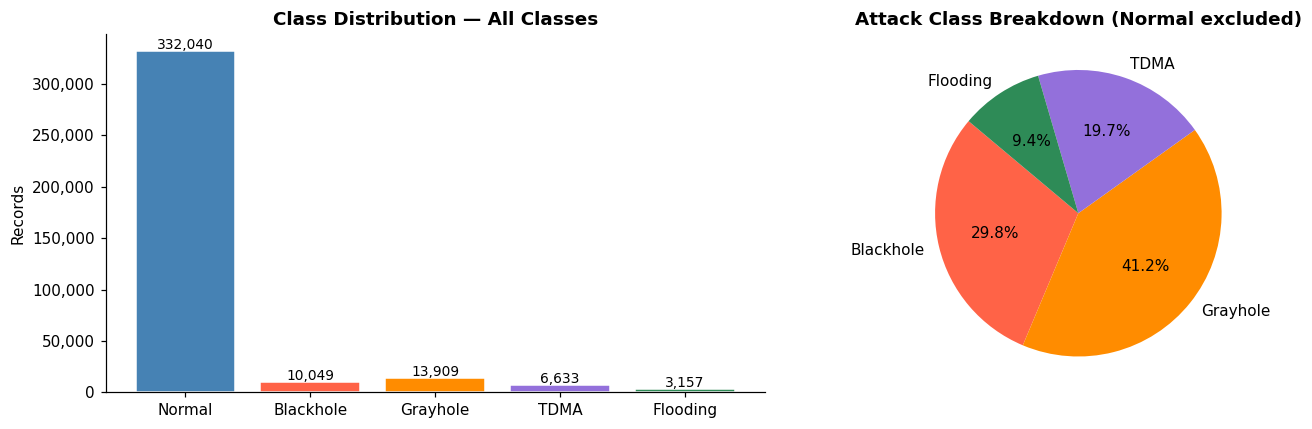

In [5]:
vc = df['Attack type'].value_counts().reindex(CLASS_ORDER)
for cls, cnt in vc.items():
    print(f'{cls:<12} {cnt:>8,}  ({cnt/len(df)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(CLASS_ORDER, vc.values, color=CLASS_COLORS, edgecolor='white')
axes[0].set_title('Class Distribution — All Classes', fontweight='bold')
axes[0].set_ylabel('Records')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)

attack_vc = vc.drop('Normal')
axes[1].pie(attack_vc.values, labels=attack_vc.index,
            colors=CLASS_COLORS[1:], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Attack Class Breakdown (Normal excluded)', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_class_distribution.png', bbox_inches='tight')
plt.show()

## Binary Label

I'm adding a binary label alongside the 5-class label: Normal=0, any attack=1. This lets me switch between binary detection (is anything wrong?) and multiclass identification (what specifically is wrong?) without rerunning preprocessing each time. Both are precomputed here.

In [6]:
LABEL_MAP = {c: i for i, c in enumerate(CLASS_ORDER)}
df['label']        = df['Attack type'].map(LABEL_MAP)
df['label_binary'] = (df['Attack type'] != 'Normal').astype(int)

bin_counts = df['label_binary'].value_counts().rename({0: 'Normal', 1: 'Attack'})
print('Binary split:')
print(bin_counts.to_string())
print(f'\nImbalance ratio: {bin_counts["Normal"]/bin_counts["Attack"]:.1f}:1  (Normal:Attack)')

Binary split:
label_binary
Normal    332040
Attack     33748

Imbalance ratio: 9.8:1  (Normal:Attack)


## Feature Correlation with Attack Label

I wanted a quick way to rank which features are most useful before going deeper. Pearson correlation with the binary label is a blunt instrument — it misses nonlinear relationships — but it narrows down what to focus on. `Is_CH` jumping out at r=0.87 was the first big clue that something unusual was going on with this dataset.

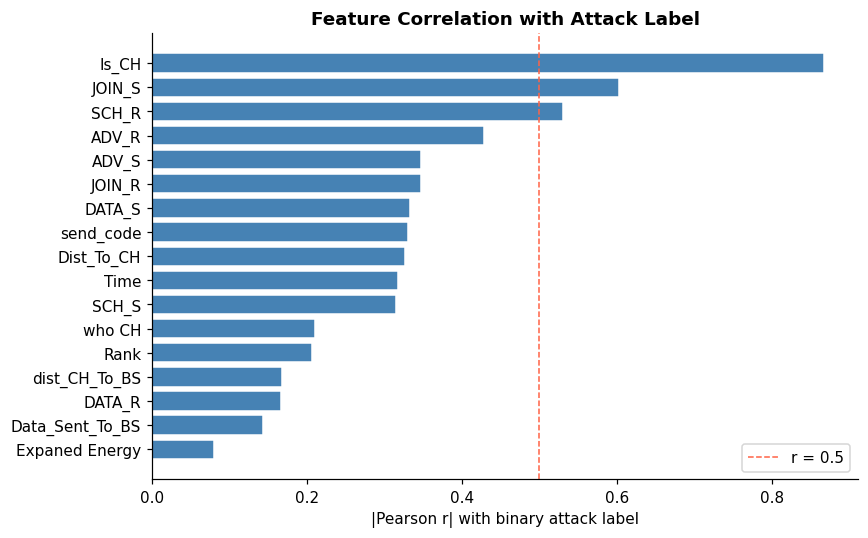

Is_CH              0.8681
JOIN_S             0.6033
SCH_R              0.5308
ADV_R              0.4284
ADV_S              0.3473
JOIN_R             0.3468
DATA_S             0.3337
send_code          0.3301
Dist_To_CH         0.3260
Time               0.3181
SCH_S              0.3145
who CH             0.2105
Rank               0.2065
dist_CH_To_BS      0.1684
DATA_R             0.1663
Data_Sent_To_BS    0.1432
Expaned Energy     0.0798


In [7]:
corrs = (df[FEATURE_COLS + ['label_binary']]
         .corr()['label_binary']
         .drop('label_binary')
         .abs()
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(corrs.index[::-1], corrs.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('|Pearson r| with binary attack label')
ax.set_title('Feature Correlation with Attack Label', fontweight='bold')
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='r = 0.5')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_feature_correlation.png', bbox_inches='tight')
plt.show()

print(corrs.round(4).to_string())

## Feature-Feature Correlation Matrix

Beyond correlations with the label, I wanted to see how features relate to *each other*. Highly correlated features carry overlapping information. Two pairs came out above |r|=0.7:

- `SCH_R` ↔ `JOIN_S`: r=0.90
- `dist_CH_To_BS` ↔ `JOIN_S`: r=0.76

This matters less for Random Forest (trees handle redundant features fine) but could cause coefficient instability if we ever try logistic regression.

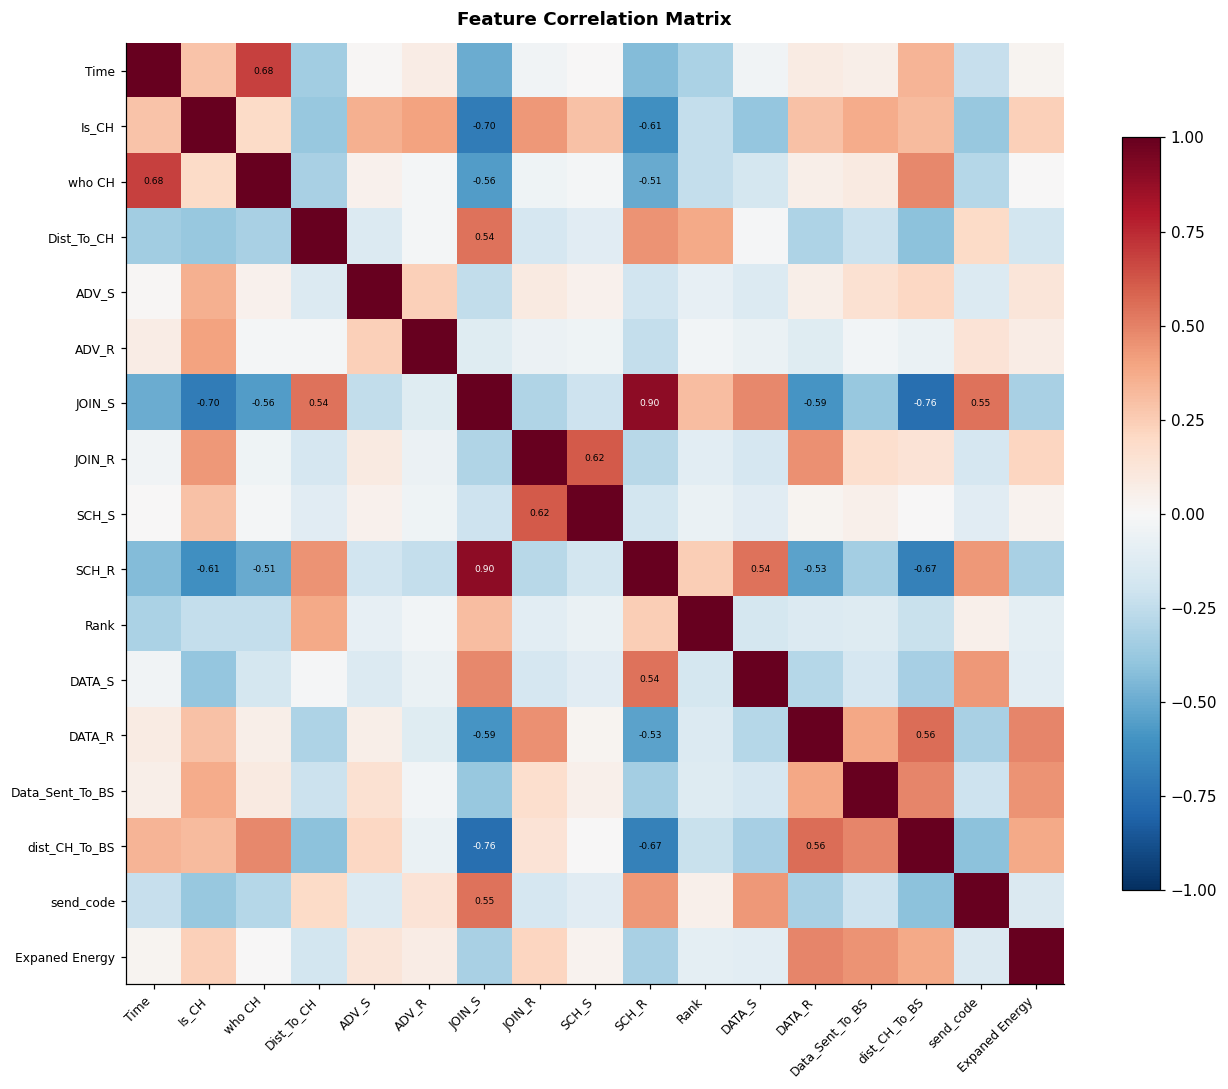

Pairs with |r| > 0.7:
  SCH_R <-> JOIN_S:  r = 0.896
  dist_CH_To_BS <-> JOIN_S:  r = -0.755


In [8]:
corr_matrix = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ticks = range(len(FEATURE_COLS))
ax.set_xticks(ticks)
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.5 and i != j:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > 0.75 else 'black')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high  = [(c, r, corr_matrix.loc[r, c]) for c in upper.columns for r in upper.index
          if pd.notna(upper.loc[r, c]) and upper.loc[r, c] > 0.7]
print('Pairs with |r| > 0.7:')
for a, b, r in sorted(high, key=lambda x: -abs(x[2])):
    print(f'  {a} <-> {b}:  r = {r:.3f}')

## Per-Class Feature Means

Correlation with the label tells me which features discriminate but not *how*. Looking at mean values per class shows the behavioral signature of each attack type. This turned out to be the most interesting part of the EDA — you can almost read off what each attack is doing just from the numbers.

In [9]:
class_means = df.groupby('Attack type')[FEATURE_COLS].mean().reindex(CLASS_ORDER).round(3)
display(class_means)

,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy
Attack type,,,,,,,,,,,,,,,,,
Normal,971.626,0.027,240660.683,25.067,0.038,6.020,0.866,0.225,0.016,0.828,10.671,49.814,60.020,3.593,18.934,2.768,0.286
Blackhole,2217.978,1.000,561877.106,0.000,1.000,17.080,0.000,5.187,0.369,0.022,0.000,0.000,305.450,0.000,0.000,0.000,0.188
Grayhole,2303.358,1.000,627412.635,0.000,1.000,19.553,0.000,3.055,0.213,0.005,0.000,0.000,181.670,12.550,75.922,0.000,0.491
TDMA,1427.755,0.936,252458.169,1.781,0.936,5.322,0.061,14.393,14.393,0.060,1.135,3.088,60.999,25.769,22.942,0.172,0.487
Flooding,710.285,1.000,314050.041,0.000,17.411,24.000,0.000,2.578,0.174,0.197,0.000,0.000,145.697,33.352,126.366,0.000,1.259


## Per-Class Distributions (Box Plots)

Means can be misleading if there's high variance. I wanted to see whether the class differences are clean separations (tight boxes at different locations) or noisy overlaps. Clean separations mean the model will have an easier time; heavy overlap means it'll need more subtle patterns.

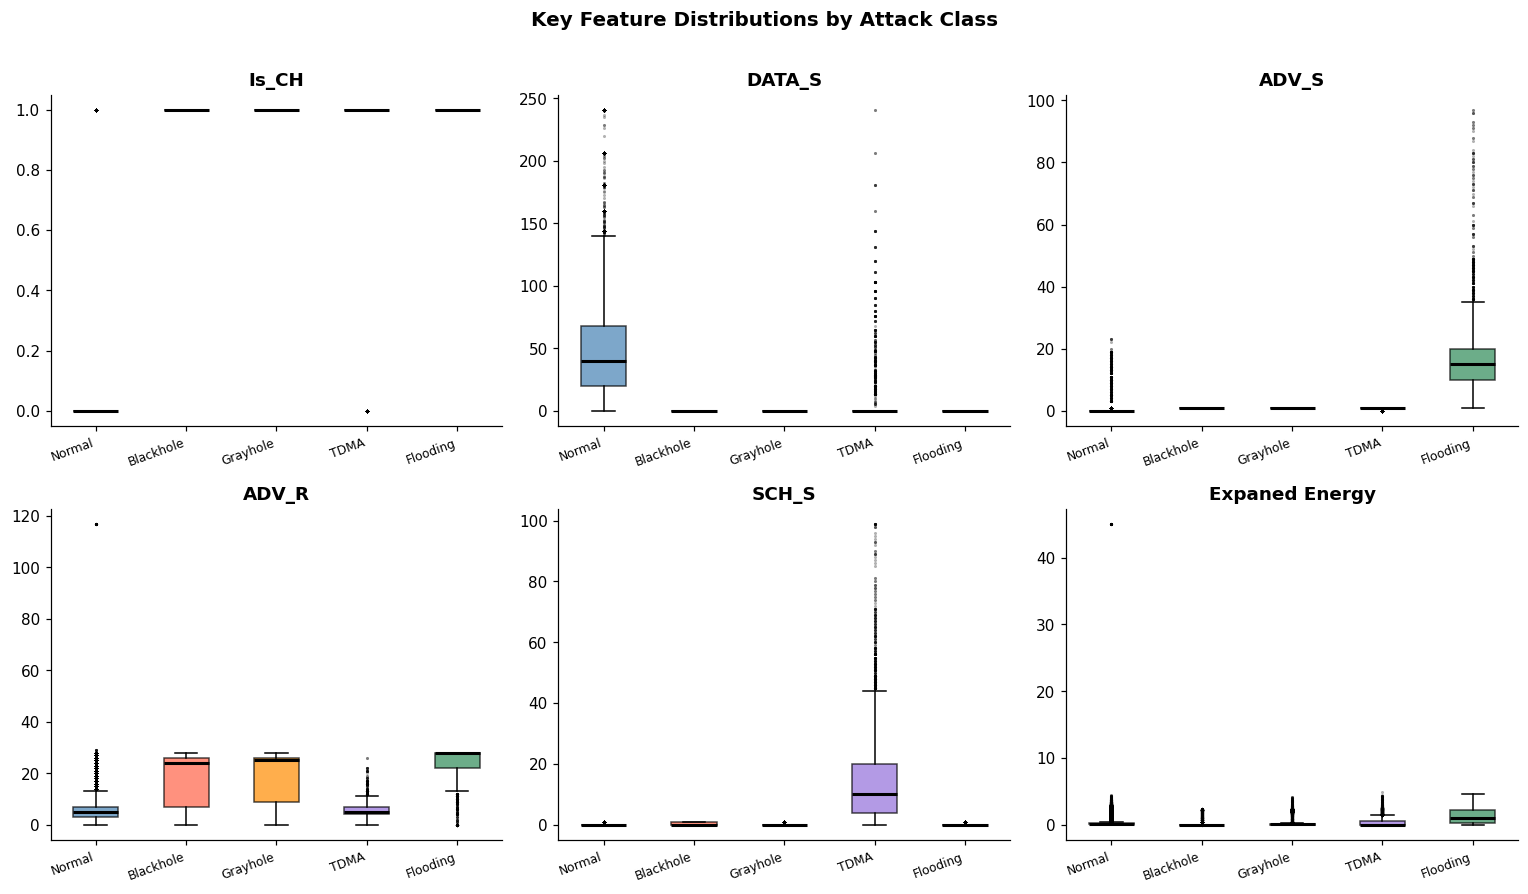

In [10]:
key_features = ['Is_CH', 'DATA_S', 'ADV_S', 'ADV_R', 'SCH_S', 'Expaned Energy']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    vals = [df[df['Attack type'] == cls][feat].values for cls in CLASS_ORDER]
    bp   = ax.boxplot(vals, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(CLASS_ORDER, rotation=20, ha='right', fontsize=8)
    ax.set_title(feat, fontweight='bold')

fig.suptitle('Key Feature Distributions by Attack Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_per_class_boxplots.png', bbox_inches='tight')
plt.show()

## The DATA_S = 0 Finding

Looking at the per-class means, `DATA_S` (data packets sent) is 0.000 for Blackhole, Grayhole, and Flooding. That's the core "hole" attack signature: these nodes accept data from child nodes but never forward it. I wanted to verify this wasn't just a low mean dragged down by a few zeroes — I wanted to know if it was literally *every* node in those classes.

In [11]:
print('Fraction of nodes with DATA_S == 0 (forwarding zero data packets):')
for cls in CLASS_ORDER:
    sub  = df[df['Attack type'] == cls]
    rate = (sub['DATA_S'] == 0).mean() * 100
    bar  = chr(9608) * int(rate / 2)
    print(f'  {cls:<12}  {rate:5.1f}%  {bar}')

Fraction of nodes with DATA_S == 0 (forwarding zero data packets):
  Normal          7.7%  ███
  Blackhole     100.0%  ██████████████████████████████████████████████████
  Grayhole      100.0%  ██████████████████████████████████████████████████
  TDMA           93.8%  ██████████████████████████████████████████████
  Flooding      100.0%  ██████████████████████████████████████████████████


## The Is_CH Finding

`Is_CH` is the dominant predictor at r=0.87 — by a lot. In the per-class means it's exactly 1.000 for Blackhole, Grayhole, and Flooding, and 0.936 for TDMA. I needed to check whether that's genuinely every single record in those classes, because if so, it means every attack in this dataset is a cluster-head impersonation attack. That's a pretty specific simulation assumption that may or may not hold in a real deployment where an attacker doesn't need to impersonate a CH to cause damage.

In [12]:
ct = pd.crosstab(df['Attack type'], df['Is_CH'], normalize='index').reindex(CLASS_ORDER)
ct.columns = ['Is_CH=0 (regular node)', 'Is_CH=1 (cluster head)']
print('Is_CH rate by attack class:')
display(ct.round(4))

Is_CH rate by attack class:


,Is_CH=0 (regular node),Is_CH=1 (cluster head)
Attack type,,
Normal,0.9727,0.0273
Blackhole,0.0000,1.0000
Grayhole,0.0000,1.0000
TDMA,0.0638,0.9362
Flooding,0.0000,1.0000


## Non-IID Federated Learning Partition Preview

The last thing I wanted to visualize before moving on: what the federated data partitions will actually look like. In a real UAV network, nodes encounter different attack types depending on their position and role. A relay UAV near an adversary might see mostly Blackhole attacks, while one in a safe zone sees Normal traffic. That's non-IID (not independently and identically distributed) data.

I'm simulating this with a Dirichlet distribution (alpha=0.5). Lower alpha = more skewed. This is why we'll need FedProx instead of plain FedAvg in the FL experiments — FedAvg assumes IID data and degrades significantly when clients have different distributions.

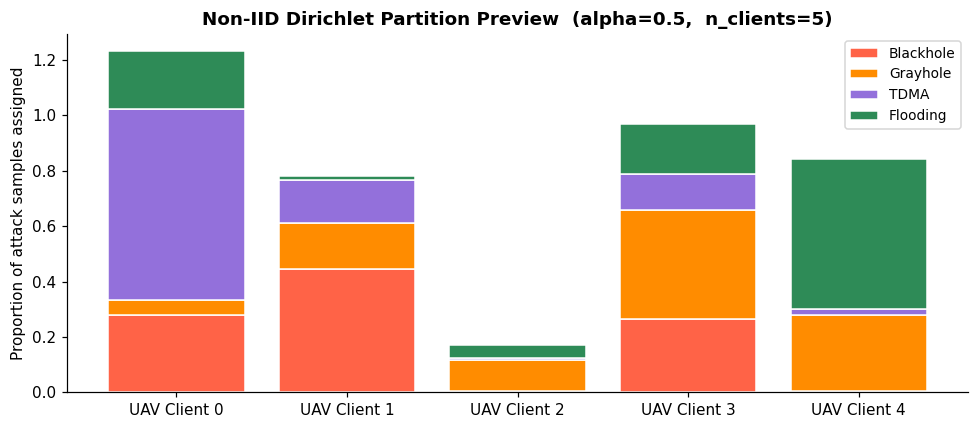

Each UAV client sees a different attack class distribution.
This is what motivates FedProx over plain FedAvg in the FL experiments.


In [13]:
rng           = np.random.default_rng(42)
n_clients     = 5
alpha         = 0.5
attack_classes = [c for c in CLASS_ORDER if c != 'Normal']

proportions = rng.dirichlet([alpha] * n_clients, size=len(attack_classes))

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(n_clients)
for i, cls in enumerate(attack_classes):
    ax.bar(range(n_clients), proportions[i], bottom=bottom,
           label=cls, color=CLASS_COLORS[i + 1], edgecolor='white')
    bottom += proportions[i]

ax.set_xticks(range(n_clients))
ax.set_xticklabels([f'UAV Client {i}' for i in range(n_clients)])
ax.set_ylabel('Proportion of attack samples assigned')
ax.set_title(f'Non-IID Dirichlet Partition Preview  (alpha={alpha},  n_clients={n_clients})',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_noniid_partition_preview.png', bbox_inches='tight')
plt.show()

print('Each UAV client sees a different attack class distribution.')
print('This is what motivates FedProx over plain FedAvg in the FL experiments.')